# K-Means Clustering from Scratch

K-Means divides a dataset into $k$ groups. It repeats two steps until nothing changes:

**1. Assign** every point $x_i$ to the nearest centroid:

$$c_i = \arg\min_{j \in \{1,\dots,k\}} \; \lVert x_i - \mu_j \rVert^2$$

**2. Update** every centroid $\mu_j$ to the mean of the points that chose it:

$$\mu_j = \frac{1}{|C_j|} \sum_{x \in C_j} x$$

where $C_j$ is the set of points assigned to cluster $j$, and the distance between two points is

$$\lVert a - b \rVert = \sqrt{\sum_{d=1}^{D} (a_d - b_d)^2}$$

Repeating those two steps drives down a single quantity, the **inertia**, which is the total
squared distance from every point to the centroid it was assigned to:

$$J = \sum_{j=1}^{k} \sum_{x \in C_j} \lVert x - \mu_j \rVert^2$$

Each step can only lower $J$ or leave it unchanged. The assignment step lowers it by moving points
to a closer centroid, and the update step lowers it because the mean is the point that minimises
the summed squared distance to a set. Since $J$ never rises and there are finitely many possible
assignments, the algorithm always stops.

This notebook implements it with NumPy and runs it on the Iris dataset. The species labels are not
used during clustering - they are only read at the end to measure how closely the clusters match
the real species.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

colors = 10 * ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7']

## Loading the data

`fetch_ucirepo(id=53)` downloads the Iris dataset. `X` becomes a 150 x 4 array of measurements,
`y` becomes an array of 150 species names, and `feature_names` holds the four column names.

In [2]:
iris = fetch_ucirepo(id=53)

X = iris.data.features.values
y = iris.data.targets.values.ravel()
feature_names = list(iris.data.features.columns)

print('measurements:', X.shape)
print('features:', feature_names)
print('species:', np.unique(y))

measurements: (150, 4)
features: ['sepal length', 'sepal width', 'petal length', 'petal width']
species: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


The cell below plots column 2 (petal length) against column 3 (petal width) with a single colour.
No labels are passed in, so this is the input the algorithm works from.

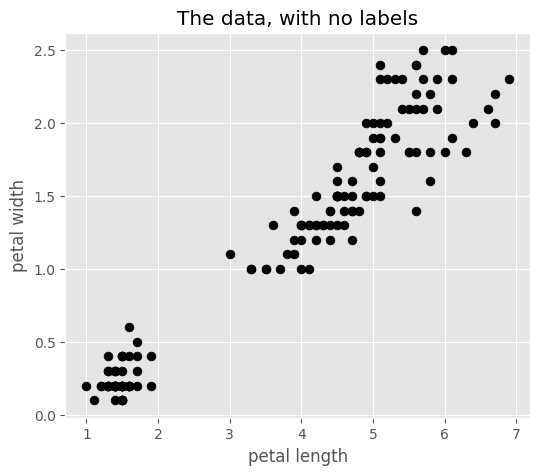

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 2], X[:, 3], s=40, color='k')
plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('The data, with no labels')
plt.show()

## The K_Means class

`__init__` stores three settings: `k` is the number of clusters, `tol` is how little the centroids
must move before the loop stops, and `max_iter` caps the number of passes.

`fit` keeps two dictionaries. `self.centroids` maps a cluster number to its centre point, and
`self.classifications` maps a cluster number to the list of points assigned to it. It starts by
using the first `k` rows of the data as the centroids. Each pass then:

- empties `self.classifications` back to `k` empty lists
- for every point, uses `np.linalg.norm` to measure the distance to each centroid, takes the index
  of the smallest with `distances.index(min(distances))`, and appends the point to that list
- copies the centroids into `prev_centroids`
- replaces each centroid with `np.average` of the points in its list
- compares each centroid against its previous position, and if none moved by more than `tol`,
  sets `optimized` to `True` and breaks

In symbols, the two lines doing the work are the assignment

$$c_i = \arg\min_j \lVert x_i - \mu_j \rVert$$

which is `distances.index(min(distances))`, and the update

$$\mu_j \leftarrow \frac{1}{|C_j|}\sum_{x \in C_j} x$$

which is `np.average(self.classifications[classification], axis=0)`. Minimising the distance and
minimising the squared distance pick the same centroid, so the code takes the plain norm.

The stopping test is

$$\sum_{d} \lvert \mu_{j,d}^{(t)} - \mu_{j,d}^{(t-1)} \rvert \le \text{tol} \quad \text{for every } j$$

so the loop ends once no centroid moved by more than `tol` on the last pass.

`predict` takes a single point, measures its distance to each centroid, and returns the index of
the closest one.

`inertia` sums the squared distance from every point to the centroid of its own cluster, which is
$J$ from the top of the notebook.

In [4]:
class K_Means:
    def __init__(self, k=3, tol=0.001, max_iter=300):
        self.k = k
        self.tol = tol
        self.max_iter = max_iter

    def fit(self, data):
        # start with the first k points as the centroids
        self.centroids = {}
        for i in range(self.k):
            self.centroids[i] = data[i]

        self.history = []

        for i in range(self.max_iter):
            # empty the buckets before every pass
            self.classifications = {}
            for j in range(self.k):
                self.classifications[j] = []

            # put each point with the closest centroid
            for featureset in data:
                distances = [np.linalg.norm(featureset - self.centroids[centroid])
                             for centroid in self.centroids]
                classification = distances.index(min(distances))
                self.classifications[classification].append(featureset)

            self.history.append(self.inertia())

            prev_centroids = dict(self.centroids)

            # move each centroid onto the average of its own points
            for classification in self.classifications:
                self.centroids[classification] = np.average(self.classifications[classification], axis=0)

            # if nothing moved by more than tol, we are finished
            optimized = True
            for c in self.centroids:
                original_centroid = prev_centroids[c]
                current_centroid = self.centroids[c]
                if np.sum(np.abs(current_centroid - original_centroid)) > self.tol:
                    optimized = False

            if optimized:
                break

        self.n_iter = i + 1

    def predict(self, data):
        distances = [np.linalg.norm(data - self.centroids[centroid]) for centroid in self.centroids]
        classification = distances.index(min(distances))
        return classification

    def inertia(self):
        # total squared distance from every point to its own centroid
        total = 0
        for classification in self.classifications:
            for featureset in self.classifications[classification]:
                total += np.linalg.norm(featureset - self.centroids[classification]) ** 2
        return total

## Running it

The cell below creates the classifier with `k=3` because Iris has 3 species, calls `fit` on the
measurements, then prints how many passes it took along with each centroid and the number of
flowers assigned to it.

## Watching the two steps alternate

The animation below replays this same fit, one step at a time. The two beats are drawn
separately on purpose: on an **assign** frame the centroids hold still and the points recolour to
whichever centroid is nearest, and on an **update** frame the colours hold still and each centroid
slides to the mean of the points that just chose it. A point that changed cluster since the last
pass is ringed in black, so the churn dying out is visible.

The panel on the right plots the inertia $J = \sum_j \sum_{x \in C_j} \lVert x - \mu_j \rVert^2$.
Both steps can only lower it - the assign step by moving points to a nearer centre, the update
step because the mean is the point that minimises squared distance to a set. That is why the loop
is guaranteed to stop.

One detail: distances are computed on all four measurements, exactly as `fit` does above, but the
plot can only show two of them. A point near a boundary can therefore look mis-coloured in the
petal plane while being correctly assigned in four dimensions.

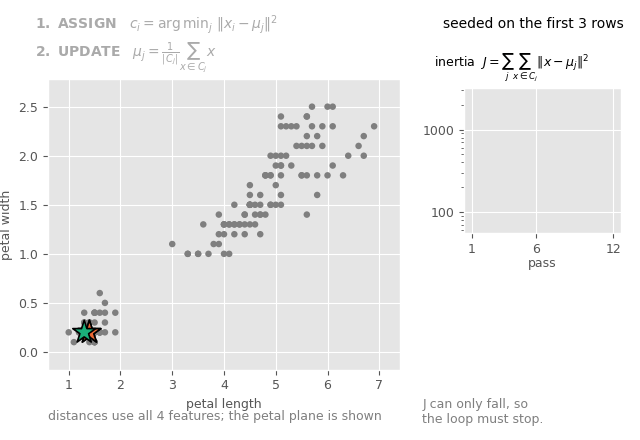

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/kmeans_lloyd.gif')

In [5]:
clf = K_Means(k=3)
clf.fit(X)

print('converged in', clf.n_iter, 'passes')
for c in clf.centroids:
    print('centroid', c, np.round(clf.centroids[c], 2), '->', len(clf.classifications[c]), 'flowers')

converged in 12 passes
centroid 0 [6.85 3.08 5.72 2.05] -> 39 flowers
centroid 1 [5.88 2.74 4.39 1.43] -> 61 flowers
centroid 2 [5.01 3.42 1.46 0.24] -> 50 flowers


## Plotting the clusters

The cell loops over `clf.classifications`, picks a colour per cluster number, and plots every point
in that cluster. It then loops over `clf.centroids` and draws each centre as a black cross.

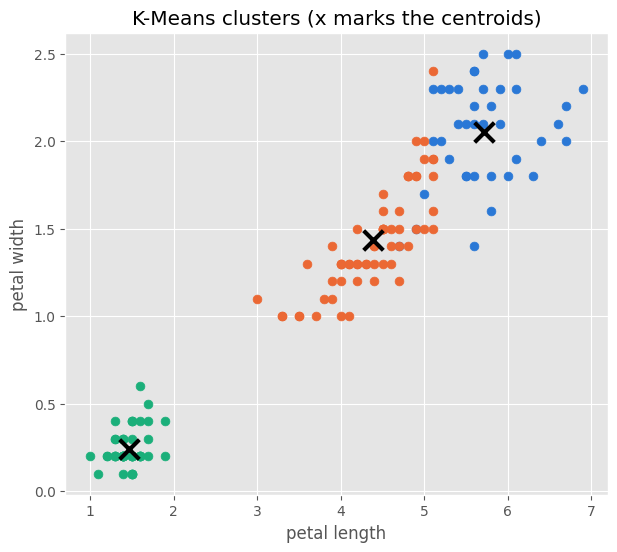

In [6]:
plt.figure(figsize=(7, 6))

for classification in clf.classifications:
    color = colors[classification]
    for featureset in clf.classifications[classification]:
        plt.scatter(featureset[2], featureset[3], color=color, s=40)

for centroid in clf.centroids:
    plt.scatter(clf.centroids[centroid][2], clf.centroids[centroid][3],
                color='k', marker='x', s=200, linewidths=3)

plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('K-Means clusters (x marks the centroids)')
plt.show()

## Comparing against the real species

The cell draws two panels on the same axes. The left one colours the points by the cluster they
were assigned to. The right one colours the same points by their true species from `y`, so the two
can be read side by side.

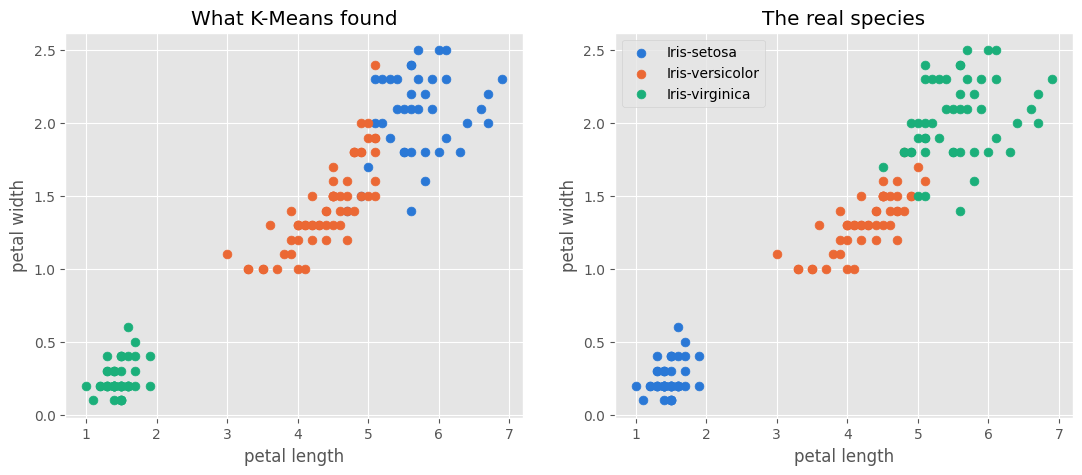

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for classification in clf.classifications:
    for featureset in clf.classifications[classification]:
        ax[0].scatter(featureset[2], featureset[3], color=colors[classification], s=40)
ax[0].set_title('What K-Means found')

for i, name in enumerate(np.unique(y)):
    ax[1].scatter(X[y == name, 2], X[y == name, 3], color=colors[i], s=40, label=name)
ax[1].set_title('The real species')
ax[1].legend()

for a in ax:
    a.set_xlabel(feature_names[2])
    a.set_ylabel(feature_names[3])

plt.show()

## Measuring accuracy

Cluster numbers are assigned in whatever order the algorithm happens to produce them, so cluster
`0` does not correspond to any particular species on its own. Each cluster is given the label that
appears in it most often,

$$\text{label}(j) = \arg\max_{c} \; \bigl|\{\, i : c_i = j \ \text{and} \ y_i = c \,\}\bigr|$$

and the score is the fraction of points whose cluster label matches their true one:

$$\text{accuracy} = \frac{1}{n} \sum_{j=1}^{k} \max_{c} \bigl|\{\, i : c_i = j \ \text{and} \ y_i = c \,\}\bigr|$$

The cell first builds `mapping`: for
each cluster it collects the true species of every point in it, uses `np.unique(..., return_counts=True)`
to count them, and assigns that cluster the most common species.

It then loops over every flower, calls `clf.predict`, looks the resulting cluster up in `mapping`,
and counts how many times it matches the true label.

In [8]:
# work out which species each cluster stands for
mapping = {}
for c in clf.classifications:
    members = [name for i, name in enumerate(y) if clf.predict(X[i]) == c]
    names, counts = np.unique(members, return_counts=True)
    mapping[c] = names[np.argmax(counts)]
    print('cluster', c, '->', mapping[c])

correct = 0
for i in range(len(X)):
    prediction = clf.predict(X[i])
    if mapping[prediction] == y[i]:
        correct += 1

print()
print(f'Accuracy: {correct / len(X)}')

cluster 0 -> Iris-virginica
cluster 1 -> Iris-versicolor
cluster 2 -> Iris-setosa

Accuracy: 0.8866666666666667


## Accuracy graphs

Inertia is the value the algorithm reduces on each pass,

$$J = \sum_{j=1}^{k} \sum_{x \in C_j} \lVert x - \mu_j \rVert^2$$

and `clf.history` already holds one reading of it per pass, recorded during `fit`. Because neither
step can increase $J$, this curve can only go down.

To get accuracy per pass, the cell repeats the same assign-and-average loop by hand, and after each
assignment step applies the same majority-vote scoring used above. The two results are plotted
against the pass number.

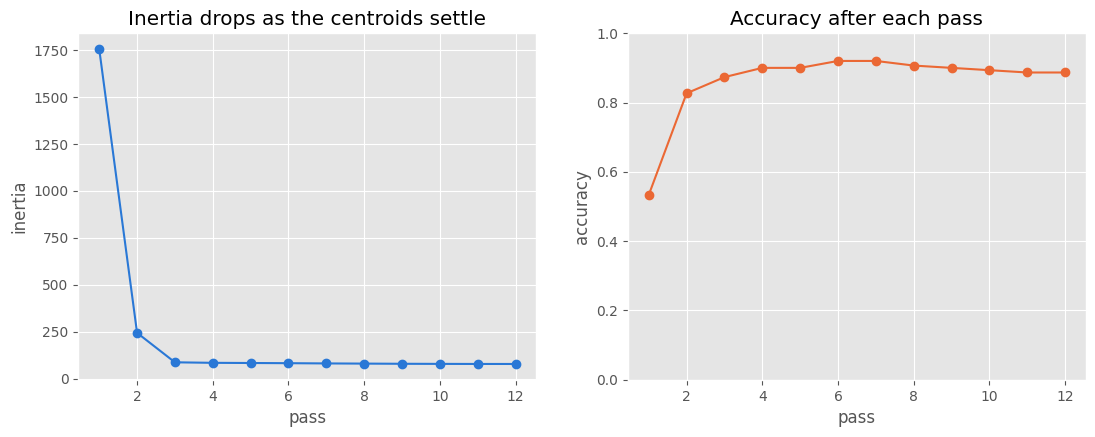

In [9]:
# step through the passes again, scoring after each one
centroids = {i: X[i] for i in range(3)}
step_accuracy = []

for step in range(clf.n_iter):
    classifications = {i: [] for i in range(3)}
    labels = []
    for featureset in X:
        distances = [np.linalg.norm(featureset - centroids[c]) for c in centroids]
        classification = distances.index(min(distances))
        classifications[classification].append(featureset)
        labels.append(classification)

    correct = 0
    for i in range(len(X)):
        members = y[np.array(labels) == labels[i]]
        names, counts = np.unique(members, return_counts=True)
        if names[np.argmax(counts)] == y[i]:
            correct += 1
    step_accuracy.append(correct / len(X))

    for c in classifications:
        centroids[c] = np.average(classifications[c], axis=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(range(1, len(clf.history) + 1), clf.history, marker='o', color=colors[0])
ax[0].set_xlabel('pass')
ax[0].set_ylabel('inertia')
ax[0].set_title('Inertia drops as the centroids settle')

ax[1].plot(range(1, len(step_accuracy) + 1), step_accuracy, marker='o', color=colors[1])
ax[1].set_xlabel('pass')
ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0, 1)
ax[1].set_title('Accuracy after each pass')

plt.show()

## Choosing k

$k$ has to be supplied before the algorithm runs, so the cell fits a separate `K_Means` for every
$k$ from 1 to 7 and records two things: the final inertia, and the majority-vote accuracy.

Inertia cannot be used directly to pick $k$, because it always falls as $k$ rises:

$$J(k+1) \le J(k), \qquad J(n) = 0$$

With one cluster per point every distance is zero, so the minimum is always at $k = n$. The useful
signal is where the curve stops falling sharply and flattens out - the "elbow", the largest $k$
past which extra clusters stop buying much.

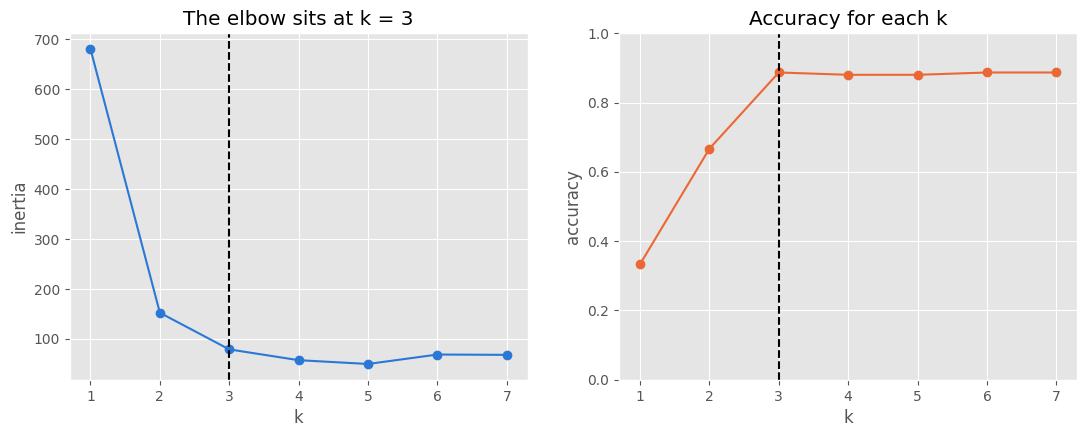

In [10]:
ks = range(1, 8)
inertias = []
accuracies = []

for k in ks:
    m = K_Means(k=k)
    m.fit(X)
    inertias.append(m.inertia())

    correct = 0
    for c in m.classifications:
        members = [y[i] for i in range(len(X)) if m.predict(X[i]) == c]
        if len(members) > 0:
            names, counts = np.unique(members, return_counts=True)
            correct += max(counts)
    accuracies.append(correct / len(X))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(ks, inertias, marker='o', color=colors[0])
ax[0].axvline(3, color='k', linestyle='--')
ax[0].set_xlabel('k')
ax[0].set_ylabel('inertia')
ax[0].set_title('The elbow sits at k = 3')

ax[1].plot(ks, accuracies, marker='o', color=colors[1])
ax[1].axvline(3, color='k', linestyle='--')
ax[1].set_xlabel('k')
ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0, 1)
ax[1].set_title('Accuracy for each k')

plt.show()

## Classifying new points

Once `fit` has run, the centroids are fixed, so `predict` can be called on measurements that were
never part of the training data. The cell defines three new sets of measurements, passes each to
`clf.predict`, looks the cluster up in `mapping` to get a species name, and plots them as stars on
top of the existing clusters.

[5.1 3.5 1.4 0.2] -> cluster 2 = Iris-setosa
[6.  2.7 4.3 1.3] -> cluster 1 = Iris-versicolor
[6.9 3.1 5.6 2.2] -> cluster 0 = Iris-virginica


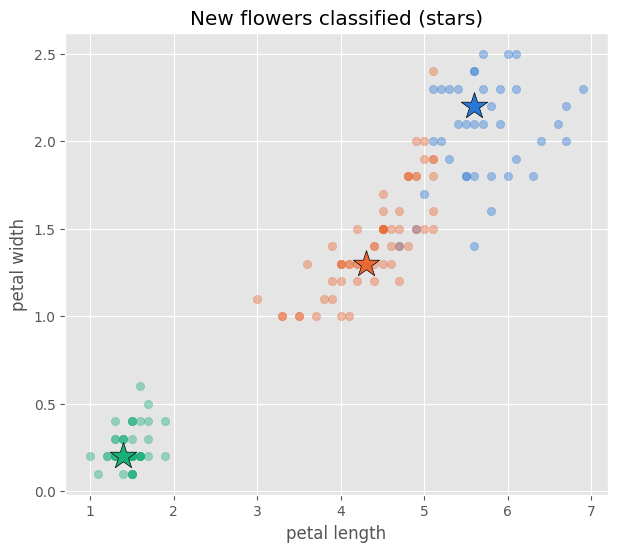

In [11]:
unknowns = np.array([[5.1, 3.5, 1.4, 0.2],
                     [6.0, 2.7, 4.3, 1.3],
                     [6.9, 3.1, 5.6, 2.2]])

plt.figure(figsize=(7, 6))

for classification in clf.classifications:
    for featureset in clf.classifications[classification]:
        plt.scatter(featureset[2], featureset[3], color=colors[classification], s=35, alpha=0.4)

for flower in unknowns:
    classification = clf.predict(flower)
    print(flower, '-> cluster', classification, '=', mapping[classification])
    plt.scatter(flower[2], flower[3], color=colors[classification],
                marker='*', s=400, edgecolors='k')

plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title('New flowers classified (stars)')
plt.show()

## Summary

- The whole algorithm is one loop: assign each point to the nearest centroid, move each centroid to
  the average of its points, stop when they stop moving.
- On Iris it stops after 12 passes and agrees with the true species on **88.7%** of the flowers.
- The elbow in the inertia curve falls at `k = 3`, which matches the number of species, and it is
  found without using the labels.
- `Iris-setosa` is separated perfectly. All of the errors are between `versicolor` and `virginica`,
  whose measurements overlap.